# SARIMA Model — Campus Waste Forecasting

This notebook trains a SARIMA (Seasonal AutoRegressive Integrated Moving Average) model for waste forecasting. SARIMA extends ARIMA by adding seasonal components, making it suitable for data with repeating patterns. The model captures both short-term autocorrelation and weekly seasonality in waste generation.

## 0. Imports

All required libraries are imported here. Statsmodels provides the SARIMAX implementation. We also import diagnostic tools for model validation.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import itertools

## 1. Hyperparameters

SARIMA has two sets of parameters: non-seasonal (p, d, q) and seasonal (P, D, Q, s). The parameter 's' is the seasonal period, set to 7 for weekly patterns. The grid search ranges can be adjusted for more exhaustive tuning.

In [2]:
# ── Forecast Settings ─────────────────────────────────────────────────────────
FORECAST_HORIZON = 7          # Days to predict ahead
TEST_DAYS = 30                # Days held out for final test evaluation
VALIDATION_DAYS = 30          # Days used for model selection

# ── SARIMA Order Parameters ───────────────────────────────────────────────────
# (p, d, q) - Non-seasonal: AR order, differencing, MA order
# (P, D, Q, s) - Seasonal: seasonal AR, seasonal differencing, seasonal MA, period

# Default parameters (used if grid search is disabled)
SARIMA_ORDER = (1, 1, 1)              # (p, d, q)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 7)  # (P, D, Q, s) - s=7 for weekly seasonality

# ── Grid Search Settings ──────────────────────────────────────────────────────
ENABLE_GRID_SEARCH = True      # Set to False to use default parameters
GRID_SEARCH_PARAMS = {
    'p': [0, 1, 2],            # AR terms
    'd': [0, 1],               # Differencing
    'q': [0, 1, 2],            # MA terms
    'P': [0, 1],               # Seasonal AR
    'D': [0, 1],               # Seasonal differencing
    'Q': [0, 1],               # Seasonal MA
    's': [7]                   # Weekly seasonality
}

# ── Exogenous Variables ───────────────────────────────────────────────────────
USE_EXOG = True
EXOG_COLS = ['Foot_Traffic', 'is_holiday', 'is_special_day']

# ── Data Path ─────────────────────────────────────────────────────────────────
DATA_PATH = 'data/waste_features_full.csv'

print("Hyperparameters loaded.")
print(f"Grid search: {'Enabled' if ENABLE_GRID_SEARCH else 'Disabled'}")

Hyperparameters loaded.
Grid search: Enabled


## 2. Helper Functions

Modular functions for data loading, stationarity testing, model fitting, and evaluation.

In [3]:
def load_data(path: str) -> pd.DataFrame:
    """Load the feature-engineered dataset and parse dates."""
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    return df


def prepare_sarima_data(df: pd.DataFrame, section: str, exog_cols: list = None):
    """
    Prepare data for SARIMA. Returns the target series with date index and optional exogenous variables.
    
    Args:
        df: Full dataset with all sections
        section: Canteen section to filter (A, B, C, or D)
        exog_cols: Optional list of exogenous variable column names
    
    Returns:
        y: Series with DatetimeIndex
        exog: DataFrame with exogenous variables (or None)
    """
    section_df = df[df['Canteen_Section'] == section].copy()
    section_df = section_df.sort_values('date').reset_index(drop=True)
    section_df = section_df.set_index('date')
    
    y = section_df['Waste_Weight_kg']
    
    exog = None
    if exog_cols:
        available_cols = [c for c in exog_cols if c in section_df.columns]
        if available_cols:
            exog = section_df[available_cols]
    
    return y, exog


def temporal_split_series(y, exog, test_days: int, val_days: int = 0):
    """
    Split time series data temporally.
    
    Returns:
        y_train, y_val, y_test, exog_train, exog_val, exog_test
    """
    n = len(y)
    test_start = n - test_days
    val_start = test_start - val_days if val_days > 0 else test_start
    
    y_train = y.iloc[:val_start]
    y_val = y.iloc[val_start:test_start] if val_days > 0 else None
    y_test = y.iloc[test_start:]
    
    exog_train, exog_val, exog_test = None, None, None
    if exog is not None:
        exog_train = exog.iloc[:val_start]
        exog_val = exog.iloc[val_start:test_start] if val_days > 0 else None
        exog_test = exog.iloc[test_start:]
    
    return y_train, y_val, y_test, exog_train, exog_val, exog_test


def test_stationarity(series: pd.Series, name: str = "Series"):
    """
    Perform Augmented Dickey-Fuller test for stationarity.
    A p-value < 0.05 suggests the series is stationary.
    """
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\nADF Test for {name}:")
    print(f"  Test Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Stationary: {'Yes' if result[1] < 0.05 else 'No (differencing may be needed)'}")
    return result[1] < 0.05


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Compute evaluation metrics for regression.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}


def baseline_moving_average(y_train, y_test, window: int = 7) -> np.ndarray:
    """
    Compute a simple moving average baseline.
    """
    all_y = pd.concat([y_train, y_test])
    train_len = len(y_train)
    
    predictions = []
    for i in range(len(y_test)):
        idx = train_len + i
        start_idx = max(0, idx - window)
        predictions.append(all_y.iloc[start_idx:idx].mean())
    
    return np.array(predictions)


def grid_search_sarima(y_train, exog_train, param_grid: dict):
    """
    Perform grid search to find optimal SARIMA parameters using AIC.
    AIC (Akaike Information Criterion) balances model fit and complexity.
    
    Returns:
        best_order, best_seasonal_order, best_aic
    """
    p_vals = param_grid['p']
    d_vals = param_grid['d']
    q_vals = param_grid['q']
    P_vals = param_grid['P']
    D_vals = param_grid['D']
    Q_vals = param_grid['Q']
    s_vals = param_grid['s']
    
    best_aic = float('inf')
    best_order = None
    best_seasonal = None
    
    total = len(list(itertools.product(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals, s_vals)))
    print(f"Grid search: testing {total} combinations...")
    
    for p, d, q, P, D, Q, s in itertools.product(p_vals, d_vals, q_vals, P_vals, D_vals, Q_vals, s_vals):
        try:
            model = SARIMAX(
                y_train,
                exog=exog_train,
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False, maxiter=100)
            
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, d, q)
                best_seasonal = (P, D, Q, s)
        except:
            continue
    
    print(f"Best parameters: order={best_order}, seasonal={best_seasonal}, AIC={best_aic:.2f}")
    return best_order, best_seasonal, best_aic


def print_metrics_comparison(baseline_metrics: dict, model_metrics: dict, model_name: str = "SARIMA"):
    """Print a formatted comparison of baseline vs model metrics."""
    print("\n" + "=" * 55)
    print(f"{'Metric':<10} {'Baseline':>12} {model_name:>12} {'Improvement':>15}")
    print("=" * 55)
    
    for metric in ['RMSE', 'MAE', 'MAPE', 'R2']:
        base_val = baseline_metrics[metric]
        model_val = model_metrics[metric]
        
        if metric == 'R2':
            improvement = model_val - base_val
            imp_str = f"+{improvement:.4f}" if improvement > 0 else f"{improvement:.4f}"
        else:
            improvement = ((base_val - model_val) / base_val) * 100 if base_val != 0 else 0
            imp_str = f"{improvement:+.1f}%"
        
        print(f"{metric:<10} {base_val:>12.4f} {model_val:>12.4f} {imp_str:>15}")
    
    print("=" * 55)

## 3. Load and Explore Data

In [4]:
df = load_data(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Sections: {sorted(df['Canteen_Section'].unique())}")
df.head()

Dataset shape: (15431, 10)
Date range: 2015-01-01 to 2025-08-10
Sections: ['A', 'B', 'C', 'D']


,date,Canteen_Section,Waste_Weight_kg,Foot_Traffic,is_holiday,is_special_day,is_weekend,weekday,month,week_of_year
0,2015-01-01,A,5.06,106.666667,1,1,0,3,1,1
1,2015-01-02,A,8.20,105.000000,0,0,0,4,1,1
2,2015-01-03,A,18.35,70.000000,0,1,1,5,1,1
3,2015-01-04,A,3.72,70.000000,0,1,1,6,1,1
4,2015-01-05,A,22.08,88.571429,0,0,0,0,1,2


## 4. Stationarity Analysis

SARIMA assumes the differenced series is stationary. We test the original series and determine if differencing is needed. The Augmented Dickey-Fuller (ADF) test checks for unit roots.

In [5]:
# Test stationarity for one section as example
sample_section = 'A'
y_sample, _ = prepare_sarima_data(df, sample_section)

print(f"Stationarity analysis for Section {sample_section}:")
is_stationary = test_stationarity(y_sample, f"Section {sample_section} Waste")

# Test after differencing
if not is_stationary:
    y_diff = y_sample.diff().dropna()
    test_stationarity(y_diff, f"Section {sample_section} Waste (1st diff)")

Stationarity analysis for Section A:

ADF Test for Section A Waste:
  Test Statistic: -62.6602
  p-value: 0.0000
  Stationary: Yes


## 5. Train and Evaluate SARIMA (All Sections)

We train a separate SARIMA model for each canteen section. If grid search is enabled, optimal parameters are found for each section. Otherwise, default parameters are used.

In [6]:
sections = sorted(df['Canteen_Section'].unique())
results = {}

for section in sections:
    print(f"\n{'='*60}")
    print(f"SECTION {section}")
    print(f"{'='*60}")
    
    # Prepare data
    exog_cols = EXOG_COLS if USE_EXOG else None
    y, exog = prepare_sarima_data(df, section, exog_cols)
    
    print(f"Total observations: {len(y)}")
    
    # Temporal split
    y_train, y_val, y_test, exog_train, exog_val, exog_test = temporal_split_series(
        y, exog, TEST_DAYS, VALIDATION_DAYS
    )
    print(f"Train: {len(y_train)} | Validation: {len(y_val) if y_val is not None else 0} | Test: {len(y_test)}")
    
    # Baseline
    baseline_pred = baseline_moving_average(y_train, y_test, window=7)
    baseline_metrics = compute_metrics(y_test.values, baseline_pred)
    print(f"\nBaseline (7-day MA): RMSE={baseline_metrics['RMSE']:.4f}")
    
    # Grid search or use defaults
    if ENABLE_GRID_SEARCH:
        # Use training + validation for grid search
        y_search = pd.concat([y_train, y_val]) if y_val is not None else y_train
        exog_search = pd.concat([exog_train, exog_val]) if exog_val is not None and exog_train is not None else exog_train
        
        best_order, best_seasonal, best_aic = grid_search_sarima(y_search, exog_search, GRID_SEARCH_PARAMS)
    else:
        best_order = SARIMA_ORDER
        best_seasonal = SARIMA_SEASONAL_ORDER
        print(f"Using default parameters: order={best_order}, seasonal={best_seasonal}")
    
    # Train final model on train+val
    y_fit = pd.concat([y_train, y_val]) if y_val is not None else y_train
    exog_fit = pd.concat([exog_train, exog_val]) if exog_val is not None and exog_train is not None else exog_train
    
    model = SARIMAX(
        y_fit,
        exog=exog_fit,
        order=best_order,
        seasonal_order=best_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted_model = model.fit(disp=False)
    
    # Forecast on test set
    forecast = fitted_model.forecast(steps=len(y_test), exog=exog_test)
    sarima_pred = forecast.values
    
    # Evaluate
    sarima_metrics = compute_metrics(y_test.values, sarima_pred)
    
    print_metrics_comparison(baseline_metrics, sarima_metrics, "SARIMA")
    
    # Store results
    results[section] = {
        'model': fitted_model,
        'order': best_order,
        'seasonal_order': best_seasonal,
        'y_train': y_fit,
        'y_test': y_test,
        'exog_train': exog_fit,
        'exog_test': exog_test,
        'predictions': sarima_pred,
        'baseline_pred': baseline_pred,
        'baseline_metrics': baseline_metrics,
        'sarima_metrics': sarima_metrics
    }


SECTION A
Total observations: 3848
Train: 3788 | Validation: 30 | Test: 30

Baseline (7-day MA): RMSE=7.3793
Grid search: testing 144 combinations...


d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be

Best parameters: order=(0, 0, 2), seasonal=(1, 1, 1, 7), AIC=24159.07


d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return ge


Metric         Baseline       SARIMA     Improvement
RMSE             7.3793       6.6993           +9.2%
MAE              6.3201       5.5295          +12.5%
MAPE            89.6967      66.3353          +26.0%
R2              -0.2016       0.0096         +0.2113

SECTION B
Total observations: 3859
Train: 3799 | Validation: 30 | Test: 30

Baseline (7-day MA): RMSE=6.7491
Grid search: testing 144 combinations...


...

d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be

Best parameters: order=(2, 0, 2), seasonal=(1, 1, 1, 7), AIC=24207.70


d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Metric         Baseline       SARIMA     Improvement
RMSE             4.8226       4.6094           +4.4%
MAE              3.7034       3.7694           -1.8%
MAPE            93.2252     107.3215          -15.1%
R2              -0.1251      -0.0278         +0.0973


d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 6. Visualize Forecasts

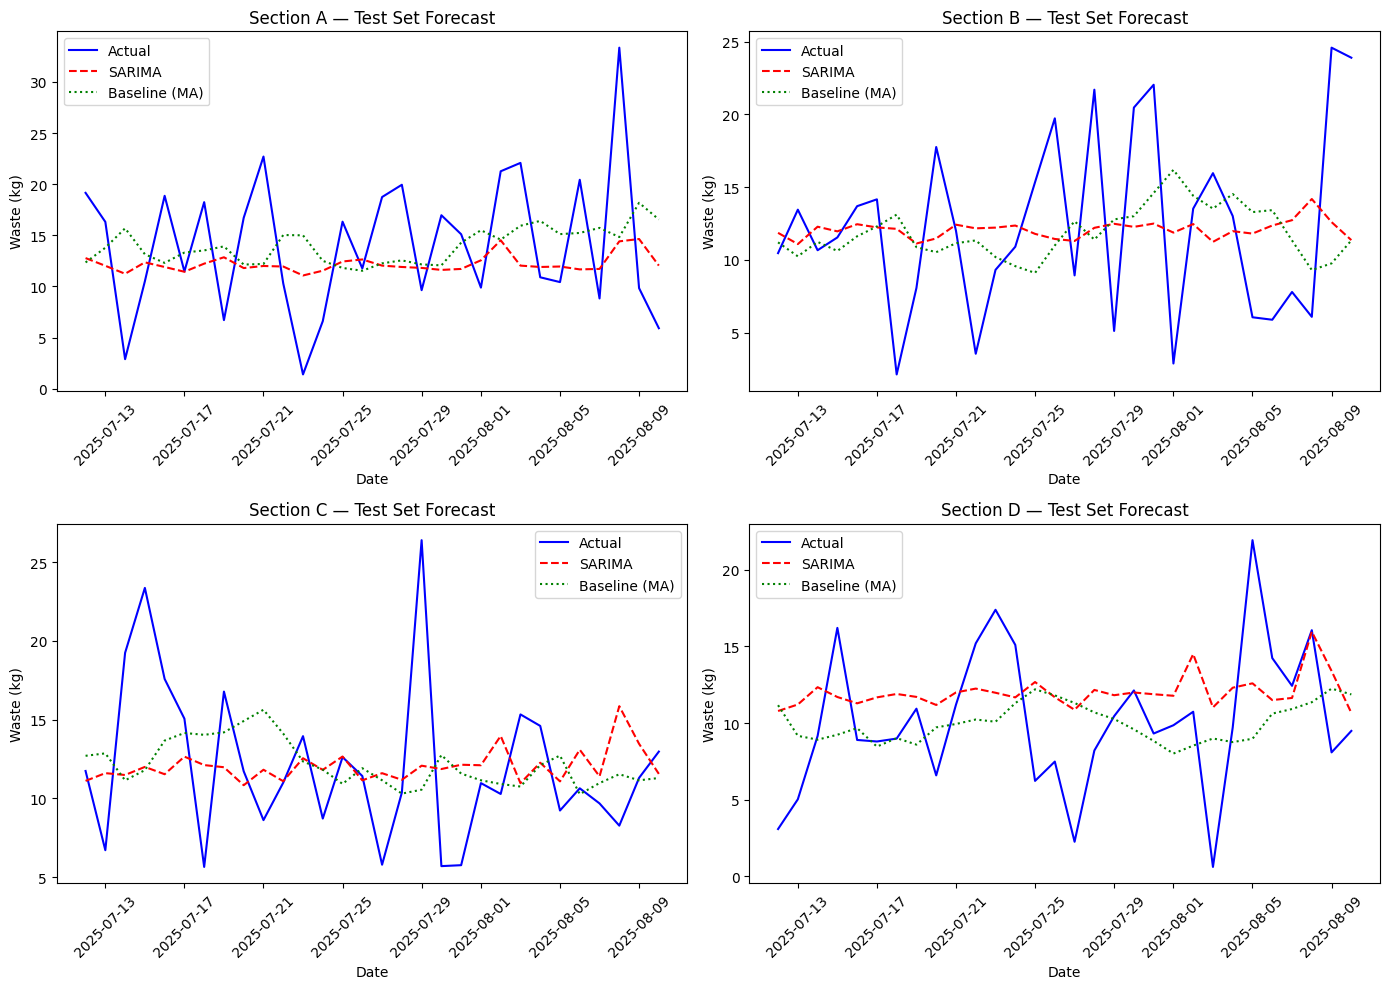

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, section in enumerate(sections):
    ax = axes[idx]
    res = results[section]
    
    test_dates = res['y_test'].index
    actual = res['y_test'].values
    
    ax.plot(test_dates, actual, 'b-', label='Actual', linewidth=1.5)
    ax.plot(test_dates, res['predictions'], 'r--', label='SARIMA', linewidth=1.5)
    ax.plot(test_dates, res['baseline_pred'], 'g:', label='Baseline (MA)', linewidth=1.5)
    
    ax.set_title(f"Section {section} — Test Set Forecast")
    ax.set_xlabel('Date')
    ax.set_ylabel('Waste (kg)')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Model Diagnostics

Check residuals to validate model assumptions. Good residuals should be normally distributed with no autocorrelation.

Model Diagnostics for Section A:
Order: (0, 0, 2)
Seasonal Order: (1, 1, 1, 7)


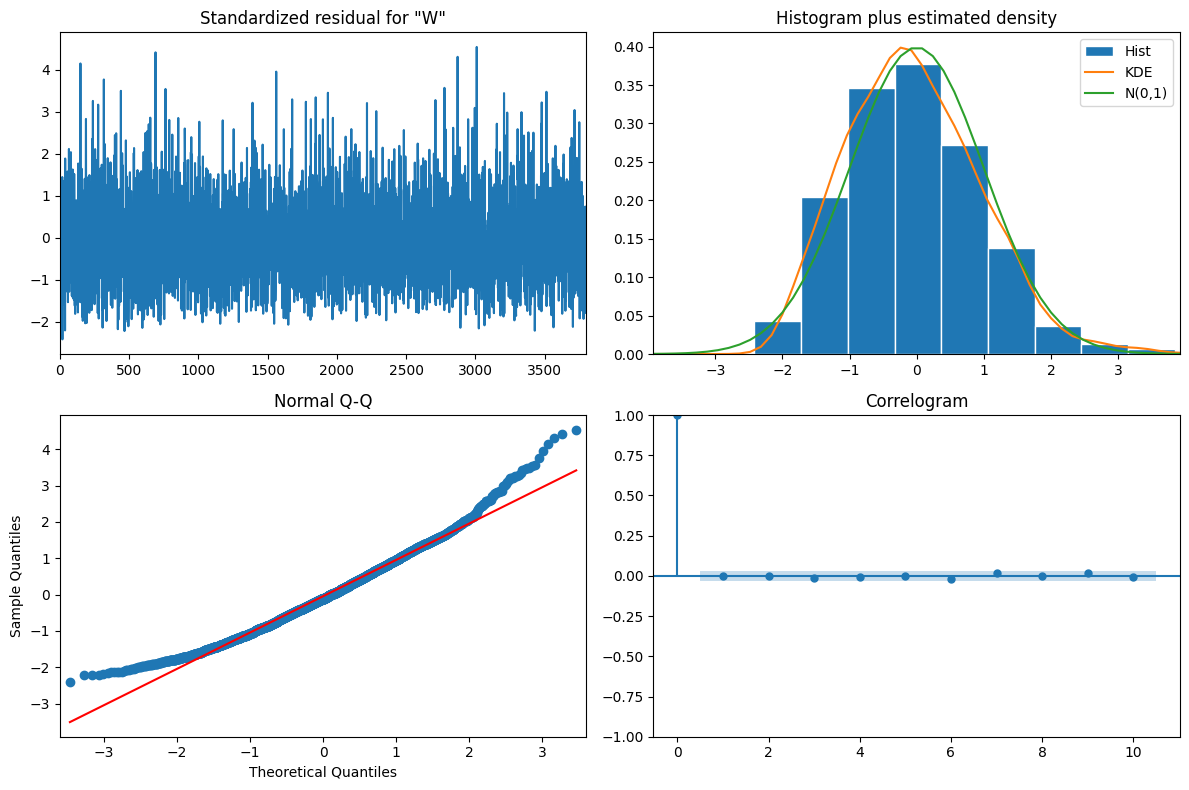


Ljung-Box Test (lag 10):
  Statistic: 3.6117
  p-value: 0.9632
  No autocorrelation: Yes


In [8]:
# Diagnostic plots for one section
sample_section = 'A'
fitted = results[sample_section]['model']

print(f"Model Diagnostics for Section {sample_section}:")
print(f"Order: {results[sample_section]['order']}")
print(f"Seasonal Order: {results[sample_section]['seasonal_order']}")

fig = fitted.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
lb_test = acorr_ljungbox(fitted.resid, lags=[10], return_df=True)
print(f"\nLjung-Box Test (lag 10):")
print(f"  Statistic: {lb_test['lb_stat'].values[0]:.4f}")
print(f"  p-value: {lb_test['lb_pvalue'].values[0]:.4f}")
print(f"  No autocorrelation: {'Yes' if lb_test['lb_pvalue'].values[0] > 0.05 else 'No'}")

## 8. Seven-Day Ahead Forecast

In [9]:
def forecast_7_days_sarima(fitted_model, last_date, exog_future=None):
    """
    Generate a 7-day ahead forecast with confidence intervals.
    
    Args:
        fitted_model: Trained SARIMAX model
        last_date: Last date in the training data
        exog_future: Exogenous variables for future dates (if model uses exog)
    
    Returns:
        DataFrame with date, predicted waste, and confidence intervals
    """
    forecast_result = fitted_model.get_forecast(steps=7, exog=exog_future)
    forecast_mean = forecast_result.predicted_mean
    conf_int = forecast_result.conf_int()
    
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')
    
    result = pd.DataFrame({
        'date': future_dates,
        'predicted_waste_kg': forecast_mean.values,
        'lower_bound': conf_int.iloc[:, 0].values,
        'upper_bound': conf_int.iloc[:, 1].values
    })
    
    return result

In [10]:
print("7-Day Ahead Forecast (from last date in data)")
print("=" * 70)

forecasts_7day = {}

for section in sections:
    res = results[section]
    last_date = res['y_test'].index.max()
    
    # Create future exogenous variables (using defaults)
    exog_future = None
    if USE_EXOG and res['exog_test'] is not None:
        future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')
        exog_future = pd.DataFrame({
            'Foot_Traffic': df['Foot_Traffic'].mean(),
            'is_holiday': 0,
            'is_special_day': 0
        }, index=future_dates)
    
    forecast_df = forecast_7_days_sarima(res['model'], last_date, exog_future)
    forecasts_7day[section] = forecast_df
    
    print(f"\nSection {section}:")
    print(forecast_df.to_string(index=False))

7-Day Ahead Forecast (from last date in data)

Section A:
      date  predicted_waste_kg  lower_bound  upper_bound
2025-08-11           13.155287     1.847392    24.463182
2025-08-12           12.491758     1.182908    23.800608
2025-08-13           12.081944     0.772714    23.391174
2025-08-14           12.064816     0.755587    23.374046
2025-08-15           11.951261     0.642039    23.260483
2025-08-16           11.939871     0.630649    23.249094
2025-08-17           12.392333     1.083110    23.701555

Section B:
      date  predicted_waste_kg  lower_bound  upper_bound
2025-08-11           12.145349     0.900708    23.389991
2025-08-12           11.553845     0.308057    22.799633
2025-08-13           11.996454     0.748865    23.244043
2025-08-14           11.766200     0.517225    23.015175
2025-08-15           12.257656     1.007624    23.507687
2025-08-16           12.021956     0.771119    23.272793
2025-08-17           11.850184     0.598733    23.101635

Section C:
      

d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\UAB\campus-waste-intelligence\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 9. Results Summary

In [11]:
print("\n" + "=" * 80)
print("OVERALL RESULTS SUMMARY")
print("=" * 80)

summary_data = []
for section in sections:
    res = results[section]
    summary_data.append({
        'Section': section,
        'Order': str(res['order']),
        'Seasonal': str(res['seasonal_order']),
        'Baseline_RMSE': res['baseline_metrics']['RMSE'],
        'SARIMA_RMSE': res['sarima_metrics']['RMSE'],
        'Baseline_R2': res['baseline_metrics']['R2'],
        'SARIMA_R2': res['sarima_metrics']['R2'],
        'Improvement_%': ((res['baseline_metrics']['RMSE'] - res['sarima_metrics']['RMSE']) / 
                          res['baseline_metrics']['RMSE'] * 100)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.round(4).to_string(index=False))

print(f"\nAverage RMSE Improvement: {summary_df['Improvement_%'].mean():.2f}%")
print(f"Average SARIMA R2: {summary_df['SARIMA_R2'].mean():.4f}")


OVERALL RESULTS SUMMARY
Section     Order     Seasonal  Baseline_RMSE  SARIMA_RMSE  Baseline_R2  SARIMA_R2  Improvement_%
      A (0, 0, 2) (1, 1, 1, 7)         7.3793       6.6993      -0.2016     0.0096         9.2158
      B (1, 0, 2) (0, 1, 1, 7)         6.7491       6.3556      -0.1790    -0.0455         5.8305
      C (2, 0, 2) (0, 1, 1, 7)         5.2713       5.0899      -0.1579    -0.0796         3.4408
      D (2, 0, 2) (1, 1, 1, 7)         4.8226       4.6094      -0.1251    -0.0278         4.4205

Average RMSE Improvement: 5.73%
Average SARIMA R2: -0.0358


## 10. Save Model

In [12]:
import pickle

os.makedirs('models', exist_ok=True)

for section in sections:
    model_path = f'models/sarima_section_{section}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump({
            'model': results[section]['model'],
            'order': results[section]['order'],
            'seasonal_order': results[section]['seasonal_order']
        }, f)
    print(f"Saved: {model_path}")

print("\nAll SARIMA models saved.")

Saved: models/sarima_section_A.pkl
Saved: models/sarima_section_B.pkl
Saved: models/sarima_section_C.pkl
Saved: models/sarima_section_D.pkl

All SARIMA models saved.
